# Project Python Foundations: FoodHub Data Analysis

### Context

The number of restaurants in New York is increasing day by day. Lots of students and busy professionals rely on those restaurants due to their hectic lifestyles. Online food delivery service is a great option for them. It provides them with good food from their favorite restaurants. A food aggregator company FoodHub offers access to multiple restaurants through a single smartphone app.

The app allows the restaurants to receive a direct online order from a customer. The app assigns a delivery person from the company to pick up the order after it is confirmed by the restaurant. The delivery person then uses the map to reach the restaurant and waits for the food package. Once the food package is handed over to the delivery person, he/she confirms the pick-up in the app and travels to the customer's location to deliver the food. The delivery person confirms the drop-off in the app after delivering the food package to the customer. The customer can rate the order in the app. The food aggregator earns money by collecting a fixed margin of the delivery order from the restaurants.

### Objective

The food aggregator company has stored the data of the different orders made by the registered customers in their online portal. They want to analyze the data to get a fair idea about the demand of different restaurants which will help them in enhancing their customer experience. Suppose you are hired as a Data Scientist in this company and the Data Science team has shared some of the key questions that need to be answered. Perform the data analysis to find answers to these questions that will help the company to improve the business.

### Data Description

The data contains the different data related to a food order. The detailed data dictionary is given below.

### Data Dictionary

* order_id: Unique ID of the order
* customer_id: ID of the customer who ordered the food
* restaurant_name: Name of the restaurant
* cuisine_type: Cuisine ordered by the customer
* cost_of_the_order: Cost of the order
* day_of_the_week: Indicates whether the order is placed on a weekday or weekend (The weekday is from Monday to Friday and the weekend is Saturday and Sunday)
* rating: Rating given by the customer out of 5
* food_preparation_time: Time (in minutes) taken by the restaurant to prepare the food. This is calculated by taking the difference between the timestamps of the restaurant's order confirmation and the delivery person's pick-up confirmation.
* delivery_time: Time (in minutes) taken by the delivery person to deliver the food package. This is calculated by taking the difference between the timestamps of the delivery person's pick-up confirmation and drop-off information

### Let us start by importing the required libraries

In [ ]:
# Installing the libraries with the specified version.
!pip install numpy==1.25.2 pandas==1.5.3 matplotlib==3.7.1 seaborn==0.13.1 -q --user

  Installing build dependencies ... done
  error: subprocess-exited-with-error
  
  × Getting requirements to build wheel did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Getting requirements to build wheel ... error
error: subprocess-exited-with-error

× Getting requirements to build wheel did not run successfully.
│ exit code: 1
╰─> See above for output.

note: This error originates from a subprocess, and is likely not a problem with pip.


**Note**: *After running the above cell, kindly restart the notebook kernel and run all cells sequentially from the start again.*

In [ ]:
# import libraries for data manipulation
import numpy as np
import pandas as pd

# import libraries for data visualization
import matplotlib.pyplot as plt
import seaborn as sns

### Understanding the structure of the data

In [ ]:
# uncomment and run the following lines for Google Colab
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Write your code here to read the data
df = pd.read_csv('/content/drive/MyDrive/foodhub_order.csv')

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Write your code here to view the first 5 rows
df.head()

,order_id,customer_id,restaurant_name,cuisine_type,cost_of_the_order,day_of_the_week,rating,food_preparation_time,delivery_time
0,1477147,337525,Hangawi,Korean,30.75,Weekend,Not given,25,20
1,1477685,358141,Blue Ribbon Sushi Izakaya,Japanese,12.08,Weekend,Not given,25,23
2,1477070,66393,Cafe Habana,Mexican,12.23,Weekday,5,23,28
3,1477334,106968,Blue Ribbon Fried Chicken,American,29.20,Weekend,3,25,15
4,1478249,76942,Dirty Bird to Go,American,11.59,Weekday,4,25,24


### **Question 1:** How many rows and columns are present in the data? [0.5 mark]

In [ ]:
# Write your code here,
df.shape

(1898, 9)

#### Observations: There are 1898 rows and 9 columns


### **Question 2:** What are the datatypes of the different columns in the dataset? (The info() function can be used) [0.5 mark]

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1898 entries, 0 to 1897
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   order_id               1898 non-null   int64  
 1   customer_id            1898 non-null   int64  
 2   restaurant_name        1898 non-null   object 
 3   cuisine_type           1898 non-null   object 
 4   cost_of_the_order      1898 non-null   float64
 5   day_of_the_week        1898 non-null   object 
 6   rating                 1898 non-null   object 
 7   food_preparation_time  1898 non-null   int64  
 8   delivery_time          1898 non-null   int64  
dtypes: float64(1), int64(4), object(4)
memory usage: 133.6+ KB


#### Observations: Using the info() function I've found that there are 9 data types listed below that has 4 integer columns, 1 float, and 4 object(string)


### **Question 3:** Are there any missing values in the data? If yes, treat them using an appropriate method. [1 mark]

In [ ]:
df.isnull().sum()

,0
order_id,0
customer_id,0
restaurant_name,0
cuisine_type,0
cost_of_the_order,0
day_of_the_week,0
rating,0
food_preparation_time,0
delivery_time,0


#### Observations: Using the isnull().sum(), we see that there is no missing values in any of the columns from the data


### **Question 4:** Check the statistical summary of the data. What is the minimum, average, and maximum time it takes for food to be prepared once an order is placed? [2 marks]

In [ ]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
order_id,1898.0,NaN,NaN,NaN,1477495.5,548.049724,1476547.0,1477021.25,1477495.5,1477969.75,1478444.0
customer_id,1898.0,NaN,NaN,NaN,171168.478398,113698.139743,1311.0,77787.75,128600.0,270525.0,405334.0
restaurant_name,1898,178,Shake Shack,219,NaN,NaN,NaN,NaN,NaN,NaN,NaN
cuisine_type,1898,14,American,584,NaN,NaN,NaN,NaN,NaN,NaN,NaN
cost_of_the_order,1898.0,NaN,NaN,NaN,16.498851,7.483812,4.47,12.08,14.14,22.2975,35.41
day_of_the_week,1898,2,Weekend,1351,NaN,NaN,NaN,NaN,NaN,NaN,NaN
rating,1898,4,Not given,736,NaN,NaN,NaN,NaN,NaN,NaN,NaN
food_preparation_time,1898.0,NaN,NaN,NaN,27.37197,4.632481,20.0,23.0,27.0,31.0,35.0
delivery_time,1898.0,NaN,NaN,NaN,24.161749,4.972637,15.0,20.0,25.0,28.0,33.0


#### Observations: With the .describe function we can check the statistical summaray of the FoodHub data that was provided.
Minimum: It takes 20 minutes for food to be prepared once an order is placed.
Average: The average time it take for food to be prepared once an order is placed is 27.37 minutes.
Maximum: It takes 35 minutes for food to be prepared once an order is placed.




### **Question 5:** How many orders are not rated? [1 mark]

In [ ]:
df['rating'].value_counts()

,count
rating,
Not given,736
5,588
4,386
3,188


#### Observations: Given that a large portion of orders do not have a rating with "Not given". Customer satisfaction appears high but also that there is a significant amount of missing feedback. For improving feedback, FoodHub can provide incentives for customers to rate their orders. This would increase the use of the app, which would ensure profits for both FoodHub and also for the restuarants.


### Exploratory Data Analysis (EDA)

### Univariate Analysis

### **Question 6:** Explore all the variables and provide observations on their distributions. (Generally, histograms, boxplots, countplots, etc. are used for univariate exploration.) [9 marks]

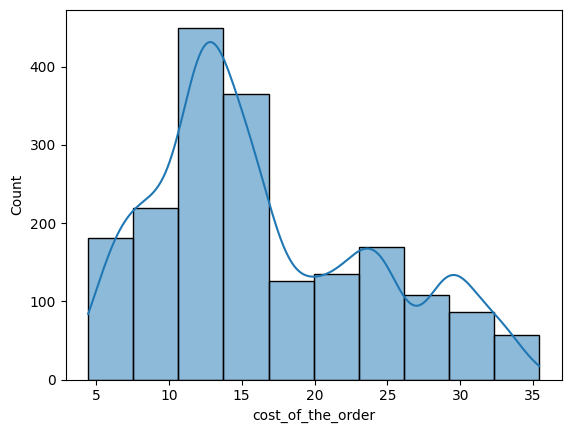

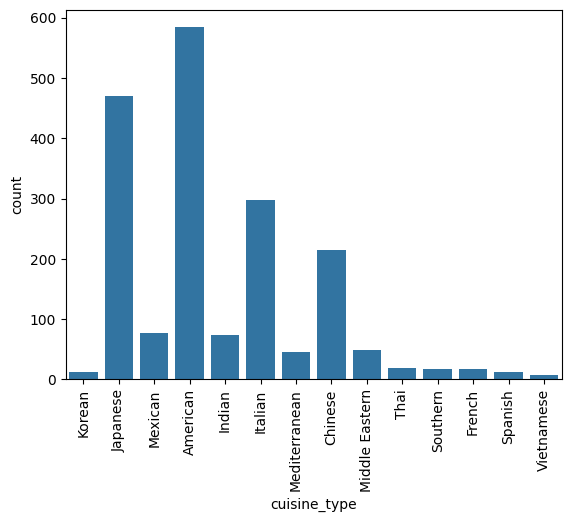

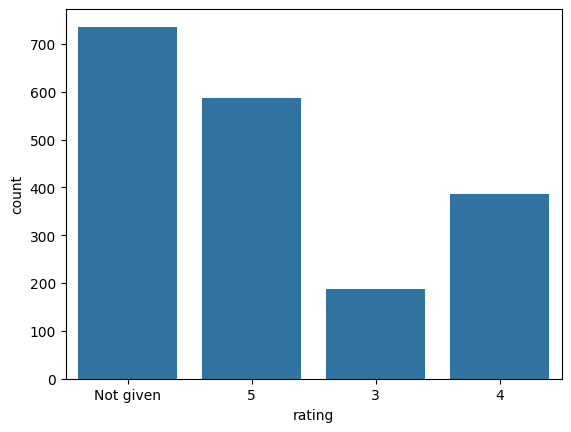

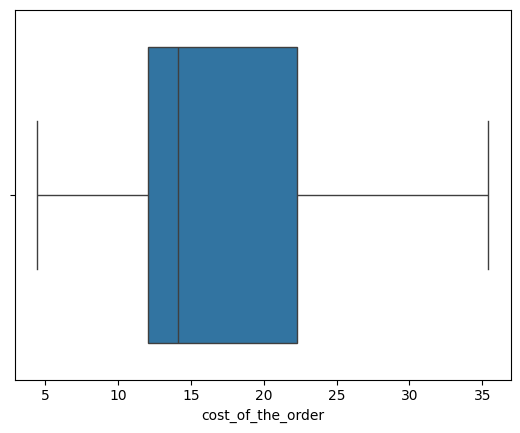

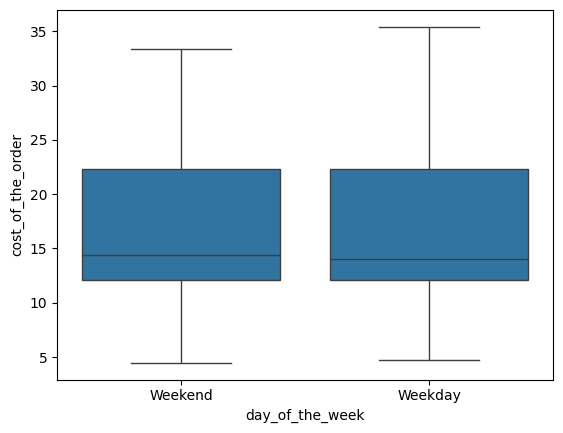

In [ ]:
sns.histplot(data=df, x='cost_of_the_order', bins=10, stat= 'count', kde=True)
plt.show()
sns.countplot(data=df, x='cuisine_type')
plt.xticks(rotation=90)
plt.show()
sns.countplot(data=df, x='rating')
plt.show()
sns.boxplot(data=df, x='cost_of_the_order')
plt.show()
sns.boxplot(data=df,x='day_of_the_week', y='cost_of_the_order')
plt.show()

### **Question 7**: Which are the top 5 restaurants in terms of the number of orders received? [1 mark]

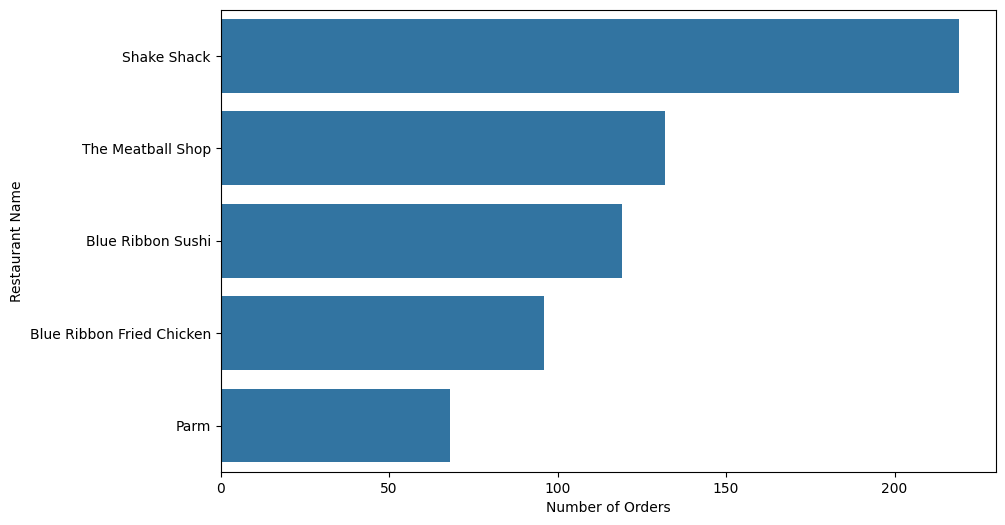

In [ ]:
# Count the number of orders for each restaurant, sorts in descending order, and gets the top 5 restaurants
top_restaurants = df['restaurant_name'].value_counts().head(5)

# Displaying results in a barplot
plt.figure(figsize=(10,6))
sns.barplot(x=top_restaurants.values, y=top_restaurants.index)
plt.xlabel("Number of Orders")
plt.ylabel("Restaurant Name")
plt.show()

#### Observations: From the shown bar graph, we can see that there is a noticeable drop after first place and then there is a tighter competition with the remaining top 4 restaurants. Also that all the order from FoodHub is pretty diversified, suggesting that customers demand is varied and not limited to just one type of cuisine.


### **Question 8**: Which is the most popular cuisine on weekends? [1 mark]

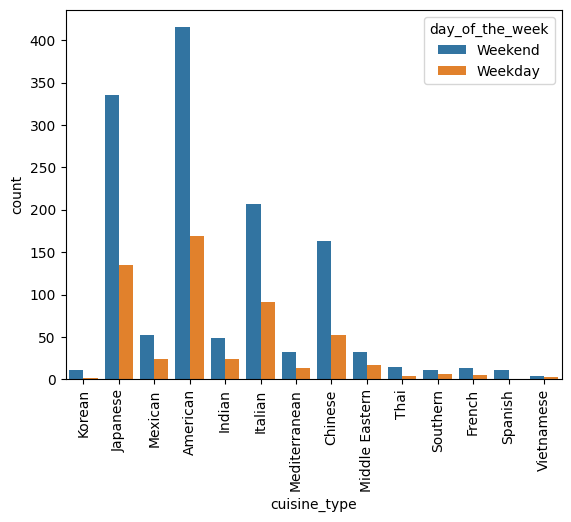

In [ ]:
sns.countplot(data=df, x='cuisine_type', hue='day_of_the_week',)
plt.xticks(rotation=90)
plt.show()

#### Observations: The popular cuisines on the weekends American. We can see that customers order out more using FoodHub on the weekends comapared to on the weekday. May be due to people not working on the weekends and also that during the weekday, they may order on FoodHub during their lunch time.


### **Question 9**: What percentage of the orders cost more than 20 dollars? [2 marks]

In [ ]:
orders_over = (df['cost_of_the_order'] > 20).sum()
total_orders = len(df)
percentage = (orders_over / total_orders) *100
print(f"Percentage of orders over 20 dollars: {percentage:.2f}%")

Percentage of orders over 20 dollars: 29.24%


#### Observations: 29.24% of Total orders cost more than 20 dollars


### **Question 10**: What is the mean order delivery time? [1 mark]

In [ ]:
#numpy mean is used to find the mean order of 'delivery_time'
df['delivery_time'].mean()

np.float64(24.161749209694417)

#### Observations: The mean of order delivery time is 24.16 minutes,


### **Question 11:** The company has decided to give 20% discount vouchers to the top 3 most frequent customers. Find the IDs of these customers and the number of orders they placed. [1 mark]

In [ ]:
#Uses count to find the top 3 customers with 'customer_id'
top_customers = df['customer_id'].value_counts().head(3)
print(top_customers)


customer_id
52832    13
47440    10
83287     9
Name: count, dtype: int64


#### Observations: Above code shows the top 3 most frequent customers on FoodHub. It also show our customers id and also the value counts of how many orders have been placed on the unique customer id.


### Multivariate Analysis

### **Question 12**: Perform a multivariate analysis to explore relationships between the important variables in the dataset. (It is a good idea to explore relations between numerical variables as well as relations between numerical and categorical variables) [10 marks]


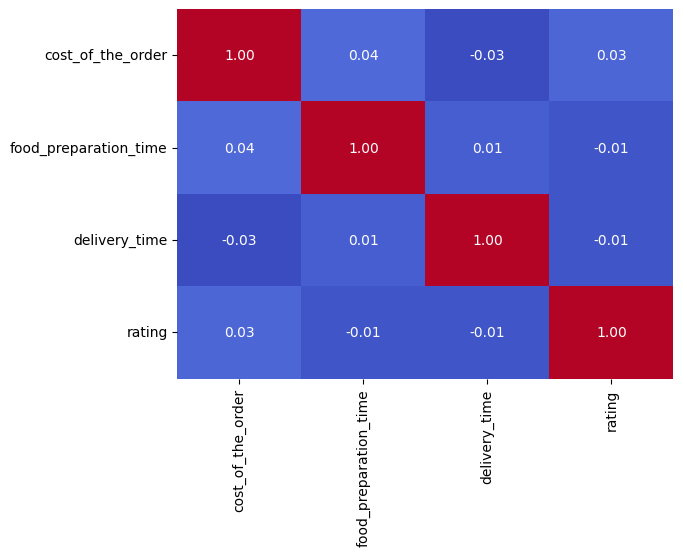

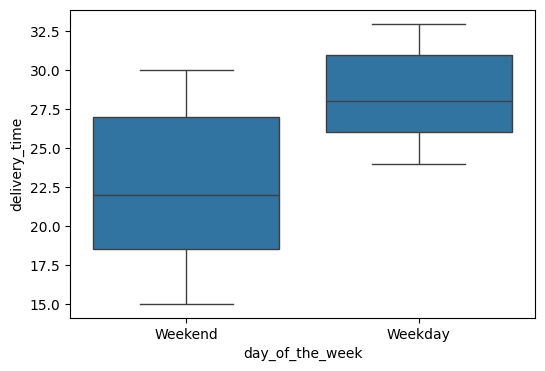

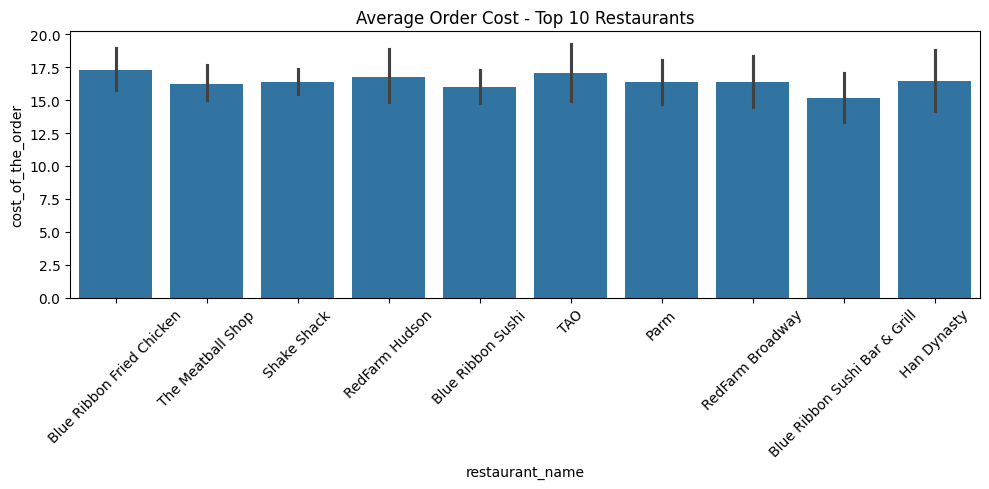

In [ ]:
# Replace 'Not given' with NaN
df['rating'] = df['rating'].replace('Not given', np.nan)

# Convert the rating column to numeric, coercing errors to NaN
df['rating'] = pd.to_numeric(df['rating'], errors='coerce')

# A heatmap is created to see if there is any relationship between cost of the order, food preparation time, and delivery time
# Observation, we can see that there is no correlation with cost of the order and food preparation time. For the cost of the order
# and delivery time, cost doesn't affect delivery speed. For food preparation time and delivery time there is no relation with longer
# prepation times doesnt affect the the delivery time.
sns.heatmap(data=df[['cost_of_the_order', 'food_preparation_time', 'delivery_time', 'rating']].corr(), annot=True, cbar=False, cmap='coolwarm', fmt='.2f')
plt.show()
plt.figure(figsize=(6,4))

# Observation: For the boxplotted day of the week and delivery time, we see that the median of delivery times for weekend is around 22 minutes
# The median of weekdays is around 28 minutes. We see that delivery times tends to be faster on the weekends rather than on the weekdays.
# I'd suggest that's because of traffic on the weekdays compared to on the weekends.
sns.boxplot(data=df, x='day_of_the_week', y='delivery_time')
plt.show()

# Gets top 10 restaurants by number of orders
# Observaton: We see that there isn't noticeable affects with the average cost of the order within the top 10 restuarants shown in the plot
top_restaurants = df['restaurant_name'].value_counts().nlargest(10).index
# Filter the dataframe
filtered_df = df[df['restaurant_name'].isin(top_restaurants)]
# Plots the barplot
plt.figure(figsize=(10,5))
sns.barplot(x='restaurant_name', y='cost_of_the_order', data=filtered_df, estimator=np.mean)
plt.xticks(rotation=45)
plt.title("Average Order Cost - Top 10 Restaurants")
plt.tight_layout()
plt.show()

### **Question 13:** The company wants to provide a promotional offer in the advertisement of the restaurants. The condition to get the offer is that the restaurants must have a rating count of more than 50 and the average rating should be greater than 4. Find the restaurants fulfilling the criteria to get the promotional offer. [3 marks]

Restaurants eligible for the promotional offer:
['Blue Ribbon Fried Chicken' 'The Meatball Shop' 'Shake Shack'
 'Blue Ribbon Sushi']


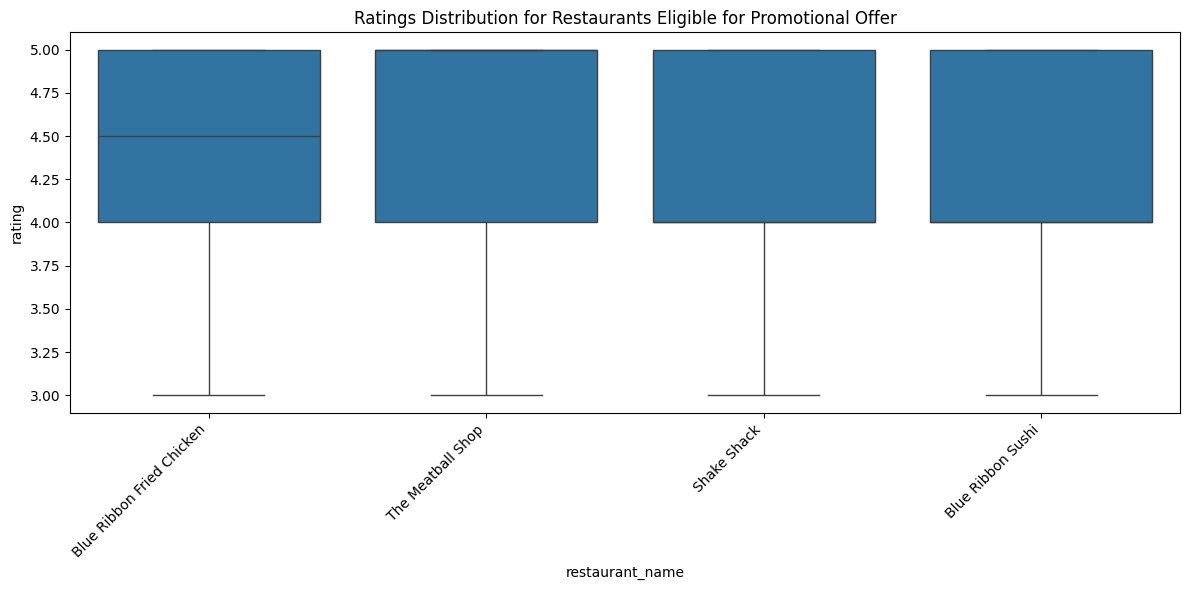

In [ ]:
# Replace 'Not given' with NaN
df['rating'] = df['rating'].replace('Not given', np.nan)

# Convert the rating column to numeric, coercing errors to NaN
df['rating'] = pd.to_numeric(df['rating'], errors='coerce')

# Group by restaurant and filter based on rating count and average rating
promotional_restaurants = df.groupby('restaurant_name').filter(lambda x: x['rating'].count() > 50 and x['rating'].mean() > 4)

# Get the unique restaurant names that meet the criteria
restaurants_for_offer = promotional_restaurants['restaurant_name'].unique()

print("Restaurants eligible for the promotional offer:")
print(restaurants_for_offer)

# Optional: Display a boxplot of ratings for the eligible restaurants
if len(restaurants_for_offer) > 0:
    plt.figure(figsize=(12, 6))
    sns.boxplot(data=df[df['restaurant_name'].isin(restaurants_for_offer)], x='restaurant_name', y='rating')
    plt.xticks(rotation=45, ha='right')
    plt.title("Ratings Distribution for Restaurants Eligible for Promotional Offer")
    plt.tight_layout()
    plt.show()
else:
    print("No restaurants meet the criteria for the promotional offer.")

#### Observations:


### **Question 14:** The company charges the restaurant 25% on the orders having cost greater than 20 dollars and 15% on the orders having cost greater than 5 dollars. Find the net revenue generated by the company across all orders. [3 marks]

In [ ]:
# Initialize cost to be from the dataset cost_of_the_order
cost = df['cost_of_the_order']
# numpy select evaluates the 'cost_of_the_order'  and assigns values from the list of choices.
rate = np.select([cost > 20, (cost > 5) & (cost <=20)], [0.25, 0.15], default = 0.0)

# Calculates the revenue per order and the total net revenue
df['comp_revenue'] = cost * rate

net_revenue = df['comp_revenue'].sum()
print(f"The net revenue across all orders: ${net_revenue:.2f}")

The net revenue across all orders: $6166.30


#### Observations: We can see that that order above 20 dollars are charged 25 percent which increases the commission revenue across all orders. Encourgaging customers to place order more than $20 could boost overall net revenue.



### **Question 15:** The company wants to analyze the total time required to deliver the food. What percentage of orders take more than 60 minutes to get delivered from the time the order is placed? (The food has to be prepared and then delivered.) [2 marks]

In [ ]:
# Created a new column to hold the values for total time required
df['total_prep_time'] = df['food_preparation_time'] + df['delivery_time']
df.head()
over_hr = (df['total_prep_time'] > 60).sum()

percentage = (over_hr / len(df)) * 100
percentage

np.float64(10.537407797681771)

#### Observations: Around 10.54% of orders takes more that 60 minutes to get delivered from the time the order is placed. This suggest that the company is efficient with the order processing and delivery time that the order is placed.


### **Question 16:** The company wants to analyze the delivery time of the orders on weekdays and weekends. How does the mean delivery time vary during weekdays and weekends? [2 marks]

In [ ]:
# We use groupby to determine the relations betweens day of the week(categorical variable) and the delivery time(numerical variable)
avg_del = df.groupby('day_of_the_week')[['delivery_time']].agg(['mean', 'sum', 'count'])
avg_del

delivery_time             
                         mean    sum count
day_of_the_week                           
Weekday             28.340037  15502   547
Weekend             22.470022  30357  1351

#### Observations: We can see that the mean of the delivery time on the weekend is shorter than on the weekdays. With the count of the delivery's we can also see people like to order more often on the weekends than on the weekdays


### Conclusion and Recommendations

### **Question 17:** What are your conclusions from the analysis? What recommendations would you like to share to help improve the business? (You can use cuisine type and feedback ratings to drive your business recommendations.) [6 marks]

### Conclusions:
*  Weekday vs Weekend trends toword have more order occuring during the weekdays compared to on the weekends. Also that the delivery time mean is shorter on the weekends compared to weekdays. It seems maybe it's due to traffic hours during the weekdays.
* There is consistent cost of average between the different types of cuisines.
* Beside there being more not given ratings, the over all ratings are mostly having very satisified customers.
*  The rating data show that 'Not Given' may correlate to longer delivery/prep times.

### Recommendations:

*  To Encourage more customers to give ratings, we could provide incentives like free delivery or a discount after they've provided a rating. This would attract more customers with places with higher ratings. This could correlate to increasing higher net revnue from commission fees and also promote order over $20.
* Although there are alot of orders on the weekends, we could also provide weekday lunch/dinner to balance the demand across the week.
* For improving delivery time on restaurants we could also track the average prep/delivery times for each restaurant to identify any outliers.
* Since the average order cost of 20 dollars or more was 29.24% FoodHub could bundle deals to boost the average order cost.
* Within finding the top 3 frequent custoemrs, we could expand a loyalty rewards program, to drive customer into using the app more frequently. The program can be tiered, making customers want to achieve higher tiers by giving discounts, free delivery, etc.

---